## Movie Review Sentiment & Theme Analysis

Goal:
Analyze movie reviews to detect sentiment and extract key themes.

Tasks:
- Sentiment Analysis (Positive / Negative / Neutral)
- Keyword Extraction
- Topic Modeling
- Visualization

In [139]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [1]:
pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud rake_nltk gensim datasets streamlit transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

d:\ML_GenAI_Project\movie-review-insights\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [132]:
import pandas as pd

df = pd.read_csv("../data/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
import nltk
import re

In [5]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [7]:
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize
    words = nltk.word_tokenize(text)

    # remove stopwords and lemmatize
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma)

    return " ".join(cleaned_words)

In [8]:
df["clean_review"] = df["review"].apply(clean_text)

In [9]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [10]:
print(df["clean_review"][0])

one reviewer mentioned watching oz episode youll hooked right exactly happened mebr br first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordbr br called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awaybr br would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned pr

In [11]:
df.to_csv("data/processed_reviews.csv", index=False)

In [12]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [13]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [14]:
df[["sentiment","label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [15]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### VADER Implementation

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
sia = SentimentIntensityAnalyzer()

In [18]:
def vader_predict(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return 0
    else:
        return 0

In [19]:
vader_preds = X_test.apply(vader_predict)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

In [21]:
vader_accuracy = accuracy_score(y_test, vader_preds)
print("VADER Accuracy:", vader_accuracy)

VADER Accuracy: 0.6777


In [22]:
print(classification_report(y_test, vader_preds))

              precision    recall  f1-score   support

           0       0.78      0.49      0.60      4961
           1       0.63      0.86      0.73      5039

    accuracy                           0.68     10000
   macro avg       0.71      0.68      0.67     10000
weighted avg       0.70      0.68      0.67     10000



### TF-IDF + Logistic Regression Implemantation

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
lr_preds = lr_model.predict(X_test_tfidf)

In [29]:
lr_accuracy = accuracy_score(y_test, lr_preds)

print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.8847
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### SVM Implementation

In [30]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [31]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8799


### Keyword Extraction

In [32]:
pip install rake-nltk

Note: you may need to restart the kernel to use updated packages.


In [33]:
from rake_nltk import Rake
import nltk

In [34]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [62]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

custom_words = [
    "movie","film","one","see","watch","time","make",
    "made","even","much","would","people","get","way"
]

stop_words.update(custom_words)

In [64]:
rake = Rake(stopwords=stop_words)

In [44]:
import re

In [45]:
def clean_html(text):
    text = re.sub(r"<.*?>", " ", text)
    return text

In [46]:
df["clean_review"] = df["review"].apply(clean_html)

In [47]:
sample_reviews = df["clean_review"].head(1000)

In [48]:
sample_reviews

0      One of the other reviewers has mentioned that ...
1      A wonderful little production.   The filming t...
2      I thought this was a wonderful way to spend ti...
3      Basically there's a family where a little boy ...
4      Petter Mattei's "Love in the Time of Money" is...
                             ...                        
995    Nothing is sacred. Just ask Ernie Fosselius. T...
996    I hated it. I hate self-aware pretentious inan...
997    I usually try to be professional and construct...
998    If you like me is going to see this in a film ...
999    This is like a zoology textbook, given that it...
Name: clean_review, Length: 1000, dtype: object

In [71]:
keywords=[]
for review in sample_reviews:
    rake.extract_keywords_from_text(review)
    phrases = rake.get_ranked_phrases()
    
    # Filter phrases with 2 or more words
    multi_word_phrases = [
        phrase for phrase in phrases if len(phrase.split()) >= 2
    ]
    
    keywords.extend(multi_word_phrases)

In [72]:
keywords

['oswald maximum security state penitentary',
 'forget pretty pictures painted',
 'uncomfortable viewing .... thats',
 'forget romance ... oz',
 'may become comfortable',
 'many .. aryans',
 'never far away',
 'middle class inmates',
 'ever saw struck',
 '1 oz episode',
 'prison bitches due',
 'forget charm',
 'first episode',
 'called oz',
 'well mannered',
 'unflinching scenes',
 'street skills',
 'shady agreements',
 'prison experience',
 'nickname given',
 'mess around',
 'mainstream audiences',
 'main appeal',
 'got accustomed',
 'glass fronts',
 'focuses mainly',
 'first thing',
 'faint hearted',
 'face inwards',
 'experimental section',
 'emerald city',
 'em city',
 'dodgy dealings',
 'death stares',
 'darker side',
 'crooked guards',
 'classic use',
 'watching oz',
 'word go',
 'high levels',
 'show pulls',
 'graphic violence',
 'murals decorating every surface',
 'realism really comes home',
 'techniques remains solid',
 'seamless editing guided',
 'scenes concerning orton',
 

In [73]:
from collections import Counter

keyword_counts = Counter(keywords)

In [74]:
keyword_counts

Counter({'ever seen': 51,
         'special effects': 32,
         'new world': 17,
         'whole thing': 15,
         'looks like': 15,
         'main character': 14,
         'real life': 13,
         'bad acting': 13,
         'felt like': 13,
         'many times': 12,
         'pretty good': 12,
         'nothing else': 11,
         'seems like': 10,
         'huge fan': 10,
         'highly recommend': 10,
         'pretty woman': 10,
         'first saw': 10,
         'well worth': 9,
         'new york': 9,
         'character development': 9,
         'second half': 9,
         'plot holes': 9,
         'worth watching': 9,
         'never seen': 9,
         'good job': 9,
         'look like': 9,
         'big screen': 9,
         'great deal': 9,
         'looked like': 8,
         'true story': 8,
         'serial killer': 8,
         'must say': 8,
         'little girl': 8,
         'well written': 8,
         'feel sorry': 8,
         'best part': 8,
         'good thi

In [75]:
keyword_counts.most_common(20)

[('ever seen', 51),
 ('special effects', 32),
 ('new world', 17),
 ('whole thing', 15),
 ('looks like', 15),
 ('main character', 14),
 ('real life', 13),
 ('bad acting', 13),
 ('felt like', 13),
 ('many times', 12),
 ('pretty good', 12),
 ('nothing else', 11),
 ('seems like', 10),
 ('huge fan', 10),
 ('highly recommend', 10),
 ('pretty woman', 10),
 ('first saw', 10),
 ('well worth', 9),
 ('new york', 9),
 ('character development', 9)]

In [76]:
import pandas as pd

keywords_df = pd.DataFrame(
    keyword_counts.most_common(20),
    columns=["keyword", "count"]
)

keywords_df

,keyword,count
0,ever seen,51
1,special effects,32
2,new world,17
3,whole thing,15
4,looks like,15
5,main character,14
6,real life,13
7,bad acting,13
8,felt like,13
9,many times,12


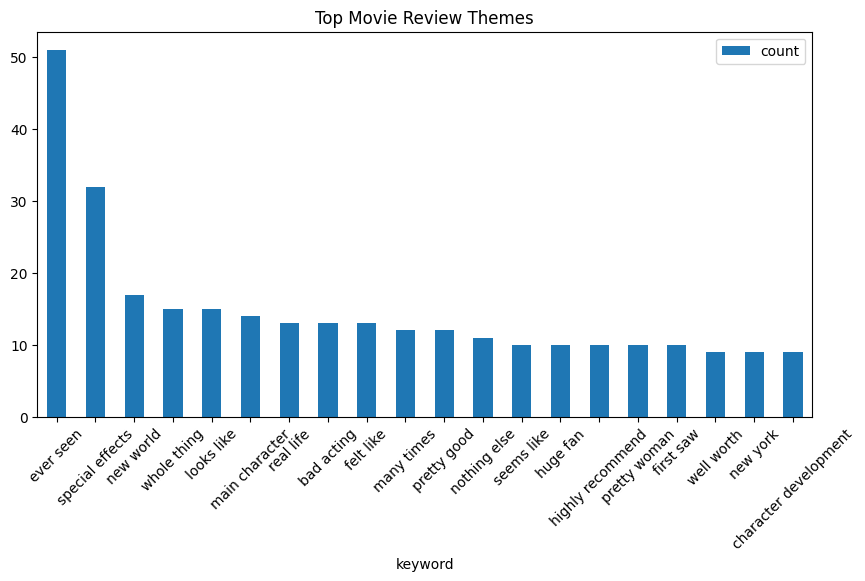

In [77]:
import matplotlib.pyplot as plt

keywords_df.plot(
    x="keyword",
    y="count",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Movie Review Themes")
plt.xticks(rotation=45)
plt.show()

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [103]:
vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=10,
    stop_words="english"
)

In [104]:
tfidf_matrix = vectorizer.fit_transform(df["clean_review"])

In [105]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4229334 stored elements and shape (50000, 25767)>

In [82]:
from sklearn.decomposition import LatentDirichletAllocation

In [106]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

In [107]:
lda.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [108]:
feature_names = vectorizer.get_feature_names_out()

In [109]:
feature_names

array(['00', '000', '007', ..., 'zulu', 'zuniga', 'über'],
      shape=(25767,), dtype=object)

In [98]:
def display_topics(model, feature_names, num_words):

    for topic_idx, topic in enumerate(model.components_):
        
        print(f"\nTopic {topic_idx+1}")
        
        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-num_words - 1:-1]
        ]
        
        print(top_words)

In [110]:
display_topics(lda, feature_names, 10)


Topic 1
['movie', 'film', 'just', 'like', 'bad', 'good', 'really', 'movies', 'don', 'watch']

Topic 2
['songs', 'movie', 'great', 'music', 'bollywood', 'musical', 'khan', 'love', 'disney', 'song']

Topic 3
['kung', 'chan', 'fu', 'hamlet', 'match', 'branagh', 'bourne', 'jackie', 'seagal', 'martial']

Topic 4
['film', 'movie', 'like', 'story', 'just', 'good', 'time', 'great', 'life', 'really']

Topic 5
['columbo', 'batman', 'scarlett', 'scooby', 'rhett', 'lonesome', 'penguin', 'mormon', 'doo', 'kurtz']


In [120]:
!pip install wordcloud

In [121]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [123]:
keywords_df

,keyword,count
0,ever seen,51
1,special effects,32
2,new world,17
3,whole thing,15
4,looks like,15
5,main character,14
6,real life,13
7,bad acting,13
8,felt like,13
9,many times,12


In [125]:
keyword_dict = dict(zip(keywords_df["keyword"], keywords_df["count"]))

In [126]:
keyword_dict

{'ever seen': 51,
 'special effects': 32,
 'new world': 17,
 'whole thing': 15,
 'looks like': 15,
 'main character': 14,
 'real life': 13,
 'bad acting': 13,
 'felt like': 13,
 'many times': 12,
 'pretty good': 12,
 'nothing else': 11,
 'seems like': 10,
 'huge fan': 10,
 'highly recommend': 10,
 'pretty woman': 10,
 'first saw': 10,
 'well worth': 9,
 'new york': 9,
 'character development': 9}

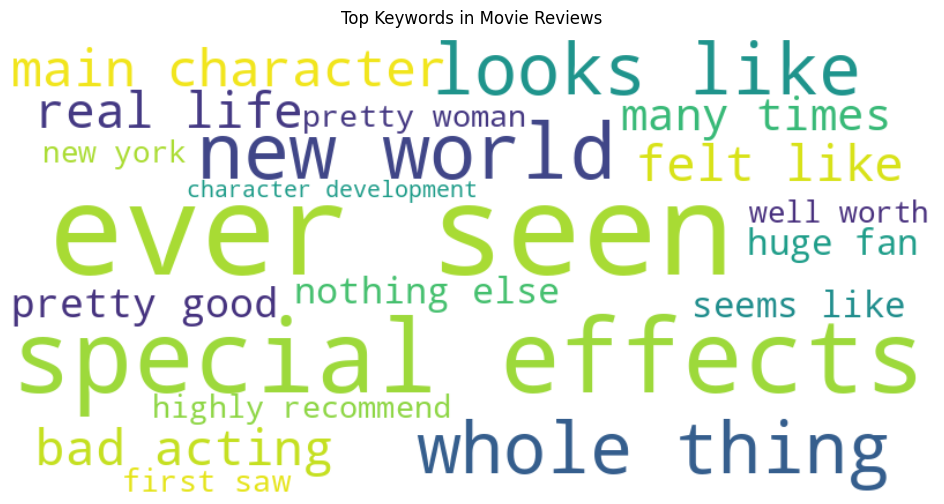

In [127]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(keyword_dict)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top Keywords in Movie Reviews")
plt.show()

In [128]:
topics = []

for topic_idx, topic in enumerate(lda.components_):
    
    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]
    
    topics.append(top_words)

In [129]:
for i, t in enumerate(topics):
    print(f"Topic {i+1}:", t)

Topic 1: ['movie', 'film', 'just', 'like', 'bad', 'good', 'really', 'movies', 'don', 'watch']
Topic 2: ['songs', 'movie', 'great', 'music', 'bollywood', 'musical', 'khan', 'love', 'disney', 'song']
Topic 3: ['kung', 'chan', 'fu', 'hamlet', 'match', 'branagh', 'bourne', 'jackie', 'seagal', 'martial']
Topic 4: ['film', 'movie', 'like', 'story', 'just', 'good', 'time', 'great', 'life', 'really']
Topic 5: ['columbo', 'batman', 'scarlett', 'scooby', 'rhett', 'lonesome', 'penguin', 'mormon', 'doo', 'kurtz']


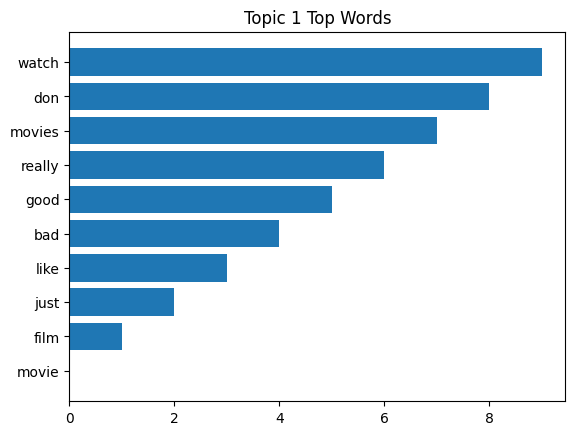

In [130]:
topic1_words = topics[0]

plt.barh(topic1_words, range(len(topic1_words)))
plt.title("Topic 1 Top Words")
plt.show()

In [133]:
import joblib

In [140]:
from src.preprocess import preprocess_dataframe
from src.sentiment import create_vectorizer, train_sentiment_models
from src.keywords import extract_keywords
from src.topic_model import train_lda_model, display_topics

In [141]:
df = preprocess_dataframe(df)

vectorizer = create_vectorizer()

X = vectorizer.fit_transform(df["clean_review"])

lr_model, svm_model = train_sentiment_models(X, df["sentiment"])

lda = train_lda_model(X)

Logistic Regression Accuracy: 0.8942
SVM Accuracy: 0.8905


In [143]:
import joblib

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")
joblib.dump(lr_model, "../models/lr_model.pkl")
joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(lda, "../models/lda_model.pkl")

['../models/lda_model.pkl']